**Fig 2. Pro-seq signals in relationship to gene structure and strand**

A. Summaries 5’, beg, end, 3’ on both strands

B. Phases (here using the bins as we have no KF yet)

C. Show phase in function of position to motivate the KF (spirals)


In [2]:
import numpy as np
import pandas as pd
from multiprocessing import Pool
from functools import partial
import matplotlib.pyplot as plt
import pyBigWig as bw
import sys
from scipy.stats import vonmises
from scipy.optimize import minimize
from scipy.special import jv
sys.path.insert(0, '/home/jbreda/PROseq/scripts/Phase_to_LabColor')
from phase_to_labcolor import phase_to_labcolor as p2lc
sys.path.insert(0, '/home/jbreda/PROseq/scripts/FourierTransform')
from fourier_transform import fourier_transform


def get_gtf(infile):

    # Read gtf file
    gtf = pd.read_csv(infile,sep='\t',header=None)
    gtf.columns = ['chr','source','type','start','end','score','strand','frame','attribute']
    gtf['gene_name'] = gtf.attribute.str.extract(r'gene_name "(.*?)";')
    N_gene = gtf.shape[0]

    # fix gene duplicates
    dup = gtf.gene_name.value_counts()
    my_genes = dup[dup>1].index
    for g in my_genes:
        idx = gtf[gtf.gene_name==g].index
        same_chr = (gtf.loc[idx,['chr','strand']].nunique().values == 1).all()
        overlap =  gtf.loc[idx,'end'].max() - gtf.loc[idx,'start'].min() < (gtf.loc[idx,'end'].values - gtf.loc[idx,'start'].values).sum()*2
        #gtf.loc[idx,['start']].values.max() < gtf.loc[idx,['end']].values.min()
        if same_chr and overlap:

            gtf.loc[idx[0],'start'] = gtf.loc[idx,'start'].min()
            gtf.loc[idx[0],'end'] = gtf.loc[idx,'end'].max()
            gtf.drop(idx[1:],inplace=True)
            
        else:
            print(g)
            gtf.loc[idx,'gene_name'] = [f'{g}_{i}' for i in range(len(idx))]
    gtf.set_index('gene_name',inplace=True,drop=True)

    return gtf


def get_count_phase_amp_in_window(coord, pseudo_count=8, genome='GRCm38'):

    # get coordinates and time points
    T = np.arange(0,48,4)
    strand_dict = {'+': 'forward', '-': 'reverse'}
    [chr,start,end,strand] = coord.split(':')
    start = int(start)
    end = int(end)

    X = np.zeros((1,len(T)))
    bw_folder = f'../results/{genome}/norm_coverage'
    for j,t in enumerate(T):

        sample = f'CT{t:02d}'
        fin = bw.open(f"{bw_folder}/{sample}/NormCoverage_3p_{strand_dict[strand]}.bw")
        vals = fin.intervals(chr,start,end)
        # get summed count for each time point
        if not vals is None:
            X[0,j] = sum([vals[i][2] for i in range(len(vals))])
    
    # get mean expression per bp
    count_per_bp = X.mean(axis=1)

    # log transform, add pseudo counts and average gene expression across bins
    X = np.log2(X + pseudo_count)

    # Get amp phase: fourier transform
    τ = 24 # period [h]
    ω = 2*np.pi/τ
    phi_n, a_n, R2, pval, mu_n = fourier_transform(X,T,ω)

    return X, count_per_bp, phi_n, a_n, R2, pval, mu_n

def get_expression_in_window(coord, bin_size,pseudo_count=8,genome='GRCm38',fill_empty_bin=True):

    T = np.arange(0,48,4)
    strand_dict = {'+': 'forward', '-': 'reverse'}
    [chr,start,end,strand] = coord.split(':')
    start = int(start)
    end = int(end)
    start_coord = max(start, 0)  # Ensure start is not negative

    # Load bigWigs to dataframe
    df = pd.DataFrame(columns=['start','end'])
    bw_folder = f'../results/{genome}/binned_norm_coverage'
    for t in T:
        sample = f'CT{t:02d}'
        fin = f"{bw_folder}/{sample}/NormCoverage_3p_{strand_dict[strand]}_bin{bin_size}bp.bw"
        with bw.open(fin,'r') as bw_file:
            # take end before the end of the chomosome
            end_coord = min(end, bw_file.chroms()[chr])

            df_t = pd.DataFrame(bw_file.intervals(chr,start_coord,end_coord),columns=['start','end',f"{t}"])
        df = pd.merge(df,df_t,on=['start','end'],how='outer')
    df.sort_values('start',inplace=True)
    df.reset_index(inplace=True,drop=True)

    # replace start and end with position in the middle of the bin, and set as index
    df['start'] = ( df.start.values + bin_size/2 ).astype(int) # bp
    df.rename(columns={'start':'pos'},inplace=True)
    df.drop('end',axis=1,inplace=True)
    df.set_index('pos',inplace=True)
    # replace NaN with 0
    df = df.astype(float)
    df.fillna(0,inplace=True)
    df = df.apply(lambda x: np.log2(x+pseudo_count),axis=1)

    # fill empty bins with 0
    if fill_empty_bin:
        start_bin = start//bin_size*bin_size + int(bin_size/2)
        end_bin = int(np.ceil(end/bin_size)*bin_size) - int(bin_size/2)
        x = np.arange(start_bin, end_bin+1, bin_size)
        positions = df.index.values
        missing_pos = np.setdiff1d(x,positions)
        if len(missing_pos) > 0:
            missing = pd.DataFrame(np.ones((missing_pos.shape[0],df.shape[1])),index=missing_pos,columns=df.columns)
            df = pd.concat([df,missing],axis=0)
            df.sort_index(inplace=True)
        
    return df

def get_flank_expression_phase(genome,bin_size,n_bins_flank,coord):
    ω = 2*np.pi/24
    T = np.arange(0,48,4)
    N = T.shape[0]

    # get gene coordinates and opposite strand ( - if + and + if -)
    chr, start, end, strand = coord
    strand_opp = '+-'.replace(strand,'')

    # get gene mean expression
    X = get_expression_in_window(f'{chr}:{start}:{end}:{strand}', bin_size)
    μ = X.values.mean()

    flank_size = n_bins_flank*bin_size
    Flanks = {}
    Flanks['sense_start']     = get_expression_in_window(f'{chr}:{start-flank_size}:{start+flank_size}:{strand}', bin_size)
    Flanks['sense_end']       = get_expression_in_window(f'{chr}:{end-flank_size}:{end+flank_size}:{strand}', bin_size)
    Flanks['antisense_start'] = get_expression_in_window(f'{chr}:{start-flank_size}:{start+flank_size}:{strand_opp}', bin_size)
    Flanks['antisense_end']   = get_expression_in_window(f'{chr}:{end-flank_size}:{end+flank_size}:{strand_opp}', bin_size)

    # make sure that the retrieved matrix have n_bins_flank+1 bins
    for flank in Flanks:
        if Flanks[flank].shape[0] != 2*n_bins_flank:
            if flank.split('_')[1] in ['start']:
                Flanks[flank] = Flanks[flank].iloc[1:,:]
            if flank.split('_')[1] in ['end']:
                Flanks[flank] = Flanks[flank].iloc[:-1,:]
    
    if strand == '-':
        # flip flanks
        Flanks['sense_start'], Flanks['sense_end'], = Flanks['sense_end'], Flanks['sense_start']
        Flanks['antisense_start'], Flanks['antisense_end'] = Flanks['antisense_end'], Flanks['antisense_start']

        # invert index order
        for flank in Flanks:
            Flanks[flank].sort_index(inplace=True,ascending=False)

    # get flanks fourrier coeff
    f_flanks = {}
    φ_flanks = {}
    μ_flanks = {}
    for flank in Flanks:
            
        idx_out = Flanks[flank].var(1) < 1e-10

        f_flanks[flank] = np.sum( Flanks[flank].values * np.exp(1j*ω*T) ,1)
        f_flanks[flank][idx_out] = np.nan

        if np.all(np.isnan(f_flanks[flank])):
            φ_flanks[flank] = np.nan
            μ_flanks[flank] = np.nan
            continue

        f_mean = np.nanmean( f_flanks[flank] )
        φ_mean = np.arctan2(np.imag(f_mean),np.real(f_mean))
        
        φ_flanks[flank] = np.arctan2(np.imag(f_flanks[flank]),np.real(f_flanks[flank])) - φ_mean
        # make sure φ is between -pi and pi
        φ_flanks[flank] = (φ_flanks[flank] + np.pi) % (2*np.pi) - np.pi

        μ_flanks[flank] = (Flanks[flank].values.mean(1) - μ)/np.log(2)
    
    return μ_flanks, φ_flanks


def get_flank_expression_phase_amp_r2(genome,bin_size,n_bins_flank,coord):
    ω = 2*np.pi/24
    T = np.arange(0,48,4)
    N = T.shape[0]

    # get gene coordinates and opposite strand ( - if + and + if -)
    chr, start, end, strand = coord
    strand_opp = '+-'.replace(strand,'')

    # get gene mean expression
    X = get_expression_in_window(f'{chr}:{start}:{end}:{strand}', bin_size)
    MU = X.values.mean()

    flank_size = n_bins_flank*bin_size
    Flanks = {}
    Flanks['sense_start']     = get_expression_in_window(f'{chr}:{start-flank_size}:{start+flank_size}:{strand}', bin_size)
    Flanks['sense_end']       = get_expression_in_window(f'{chr}:{end-flank_size}:{end+flank_size}:{strand}', bin_size)
    Flanks['antisense_start'] = get_expression_in_window(f'{chr}:{start-flank_size}:{start+flank_size}:{strand_opp}', bin_size)
    Flanks['antisense_end']   = get_expression_in_window(f'{chr}:{end-flank_size}:{end+flank_size}:{strand_opp}', bin_size)

    # make sure that the retrieved matrix have n_bins_flank+1 bins
    for flank in Flanks:
        if Flanks[flank].shape[0] != 2*n_bins_flank:
            if flank.split('_')[1] in ['start']:
                Flanks[flank] = Flanks[flank].iloc[1:,:]
            if flank.split('_')[1] in ['end']:
                Flanks[flank] = Flanks[flank].iloc[:-1,:]
    
    if strand == '-':
        # flip flanks
        Flanks['sense_start'], Flanks['sense_end'], = Flanks['sense_end'], Flanks['sense_start']
        Flanks['antisense_start'], Flanks['antisense_end'] = Flanks['antisense_end'], Flanks['antisense_start']

        # invert index order
        for flank in Flanks:
            Flanks[flank].sort_index(inplace=True,ascending=False)

    # get flanks phase
    f_flanks = {}
    φ_flanks = {}
    μ_flanks = {}
    A_flanks = {}
    R2_flanks = {}
    for flank in Flanks:

        x = Flanks[flank].values
            
        idx_out = x.var(1) < 1e-10

        f_flanks[flank] = np.sum( x * np.exp(1j*ω*T) ,1)
        f_flanks[flank][idx_out] = np.nan

        if np.all(np.isnan(f_flanks[flank])):
            φ_flanks[flank] = np.nan
            μ_flanks[flank] = np.nan
            A_flanks[flank] = np.nan
            R2_flanks[flank] = np.nan
            continue
        
        μ = x.mean(1)
        φ = np.arctan2(np.imag(f_flanks[flank]),np.real(f_flanks[flank]))
        A = 2*np.abs(f_flanks[flank])/N
        
        x_hat = μ[:,None] + A[:,None] * np.cos(ω * T[None,:] - φ[:,None])
        sig2_res = np.var(x - x_hat,1)
        sig2_tot = np.var(x,1)
        R2 = np.zeros(sig2_res.shape)
        R2[sig2_tot==0] = 0
        R2[sig2_tot!=0] = 1 - sig2_res[sig2_tot!=0] / sig2_tot[sig2_tot!=0]

        f_mean = np.nanmean( f_flanks[flank] )
        φ_mean = np.arctan2(np.imag(f_mean),np.real(f_mean))
        
        # make sure φ is between -pi and pi
        μ_flanks[flank] = μ - MU
        φ_flanks[flank] = φ - φ_mean
        φ_flanks[flank] = (φ_flanks[flank] + np.pi) % (2*np.pi) - np.pi
        A_flanks[flank] = A
        R2_flanks[flank] = R2

    return μ_flanks, φ_flanks, A_flanks, R2_flanks

def plot_gene_phase_amp(gene_phase_amp, th):

    to_plot = ['log10_length','log10_mean_count_per_bp','-log10_pval']

    fig, axes = plt.subplots(2,2,figsize=(10,6))
    for i,col in enumerate(to_plot):
        x = gene_phase_amp[col]
        x = x[~np.isnan(x)]
        x = x[~np.isinf(x)]
        ax = axes[i//2,i%2]
        ax.hist(x,bins=100)
        ax.axvline(th[col],color='r')
        ax.set_xlabel(col.replace('_',' '))
        ax.set_ylabel('Nr. of genes')

    
    ax = axes[1,1]
    h = ax.scatter(gene_phase_amp['log10_length'],gene_phase_amp['-log10_pval'],c=gene_phase_amp['log10_mean_count_per_bp'],s=1,cmap='coolwarm',alpha=0.5)
    ax.axvline(th['log10_length'],color='r')
    ax.axhline(th['-log10_pval'],color='r')
    ax.set_xlabel('log10_length'.replace('_',' '))
    ax.set_ylabel('-log10_pval'.replace('_',' '))
    plt.colorbar(h,label='log10_mean_count_per_bp'.replace('_',' '),ax=ax)

    plt.tight_layout()
    return fig

6564


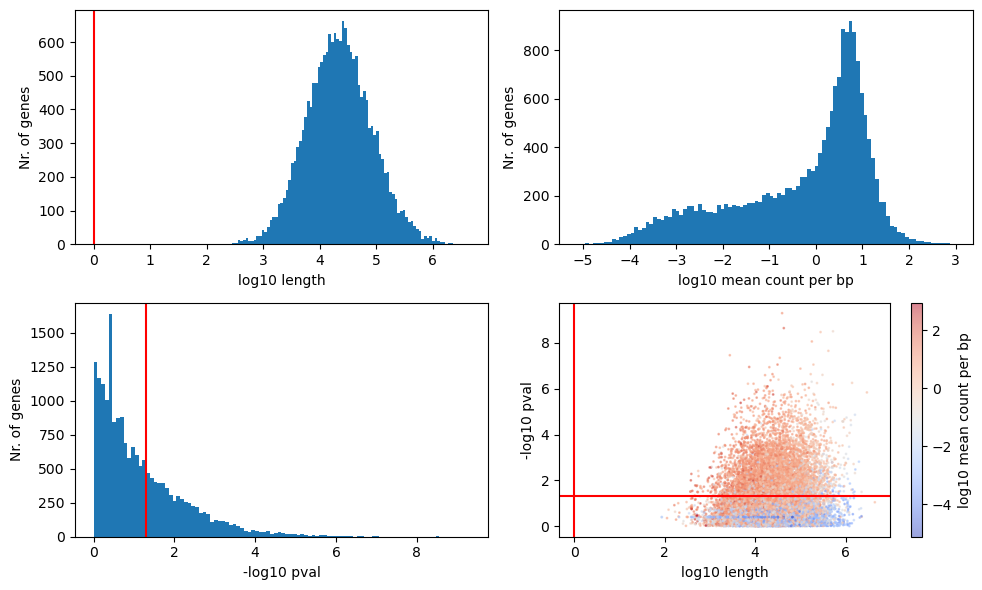

In [19]:
genome = 'GRCm38'
bin_size = 100 # bin size
n_bins_flank = 500

T = np.arange(0,48,4) # time points [h]
τ = 24 # period [h]
ω = 2*np.pi/τ # angular frequency [rad/h]
m = len(T) # number of time points
dx = bin_size # distance between positions [bp]

file_gene_phase = f'../results/{genome}/phase_amp/gene_phase_amp.csv'
gene_phase_amp = pd.read_csv(file_gene_phase,index_col=-1,sep='\t')
gene_phase_amp['length'] = gene_phase_amp['end'] - gene_phase_amp['start']
# remove genes with 0 count per bp
gene_phase_amp = gene_phase_amp[gene_phase_amp['mean_count_per_bp'] > 0]
# get log 10 of length, mean count per bp, and pval
gene_phase_amp['log10_length'] = np.log10(gene_phase_amp['length'])
gene_phase_amp['log10_mean_count_per_bp'] = np.log10(gene_phase_amp['mean_count_per_bp'])
gene_phase_amp['-log10_pval'] = -np.log10(gene_phase_amp['pval'])

# Thresholds
th = {'log10_length': 0,
      'log10_mean_count_per_bp': -np.inf,
      '-log10_pval': 1.3}

fig = plot_gene_phase_amp(gene_phase_amp, th)

idx_top = np.ones(gene_phase_amp.shape[0],dtype=bool)
for i in th:
    idx_top = idx_top & (gene_phase_amp[i].values > th[i])
    
idx_top = np.where(idx_top)[0]

print(len(idx_top))
# get genes relative expression along its body


In [20]:

Flank_rel_expression = {}
Flank_rel_phase = {}
Flank_amp = {}
Flank_R2 = {}
for strand in ['sense','antisense']:
    for pos in ['start','end']:
        flank = f'{strand}_{pos}'
        Flank_rel_expression[flank] = np.zeros((len(idx_top),2*n_bins_flank))*np.nan
        Flank_rel_phase[flank] = np.zeros((len(idx_top),2*n_bins_flank))*np.nan
        Flank_amp[flank] = np.zeros((len(idx_top),2*n_bins_flank))*np.nan
        Flank_R2[flank] = np.zeros((len(idx_top),2*n_bins_flank))*np.nan


COORD = [gene_phase_amp.loc[gene_phase_amp.index[i],['chr','start','end','strand']].values for i in idx_top]

with Pool(96) as p:
    OUT = p.map(partial(get_flank_expression_phase_amp_r2, genome, bin_size, n_bins_flank),COORD)

for g,gene in enumerate(gene_phase_amp.iloc[idx_top].index):
    for flank in Flank_rel_expression:
        Flank_rel_expression[flank][g,:] = OUT[g][0][flank]
        Flank_rel_phase[flank][g,:] = OUT[g][1][flank]
        Flank_amp[flank][g,:] = OUT[g][2][flank]
        Flank_R2[flank][g,:] = OUT[g][3][flank]


In [21]:
bins = np.linspace(-np.pi,np.pi,101)

Flank_rel_expression[flank][np.isnan(Flank_rel_expression[flank])] = 0
#Flank_rel_phase[flank][np.isnan(Flank_rel_phase[flank])] = 0
Flank_amp[flank][np.isnan(Flank_amp[flank])] = 0
Flank_R2[flank][np.isnan(Flank_R2[flank])] = 0

H = {}
VM = {}
MU_SIGMA2 = {}
for flank in Flank_rel_phase:

    H[flank] = np.zeros((len(bins)-1,2*n_bins_flank))
    VM[flank] = np.zeros((len(bins)-1,2*n_bins_flank))*np.nan
    MU_SIGMA2[flank] = np.zeros((2,2*n_bins_flank))*np.nan
    for b in range(2*n_bins_flank):

        dφ = Flank_rel_phase[flank][:,b]
        w = Flank_amp[flank][:,b] * Flank_R2[flank][:,b]
        w = w / np.nansum(w)  # normalize weights

        #dφ = np.nanmean(Flank_rel_phase[flank][:,max(0,b-2):min(2*n_bins_flank,b+3)],axis=1)
        #w = Flank_amp[flank][:,max(0,b-2):min(2*n_bins_flank,b+3)].mean(axis=1) * Flank_R2[flank][:,max(0,b-2):min(2*n_bins_flank,b+3)].mean(axis=1)
        #w = w / np.nansum(w)  # normalize weights
        [h,x] = np.histogram(dφ, bins=bins, weights=w, density=True)
        [h,x] = np.histogram(dφ, bins=bins, density=True)
        H[flank][:,b] = h

        # fit a vonmises distribution
        loc0 = 0
        κ0 = 0
        scale = 1
        x = (x[1:] + x[:-1])/2
        # find the loc and κ that minimize mse between h and vm
        fun = lambda θ: np.mean((vonmises.pdf(x, loc=θ[0], kappa=θ[1], scale=scale) - h)**2)
        res = minimize(fun=fun, x0=[loc0, κ0], bounds=[(-np.pi, np.pi),(0, None)])

        if res.success:
            loc, κ  = res.x
            VM[flank][:,b] = vonmises.pdf(x, loc=loc, kappa=κ, scale=scale)
            μ = loc
            σ2 = (1 - jv(1,κ)/jv(0,κ))
            MU_SIGMA2[flank][:,b] = [μ, σ2]

        else:
            print(f"Optimization failed for {flank} bin {b}")
            VM[flank][:,b] = 1/(2*np.pi)  # uniform distribution
            MU_SIGMA2[flank][:,b] = [np.nan, np.nan]




/tmp/ipykernel_85115/113015750.py:94: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(-2*np.log(R_1_m) )


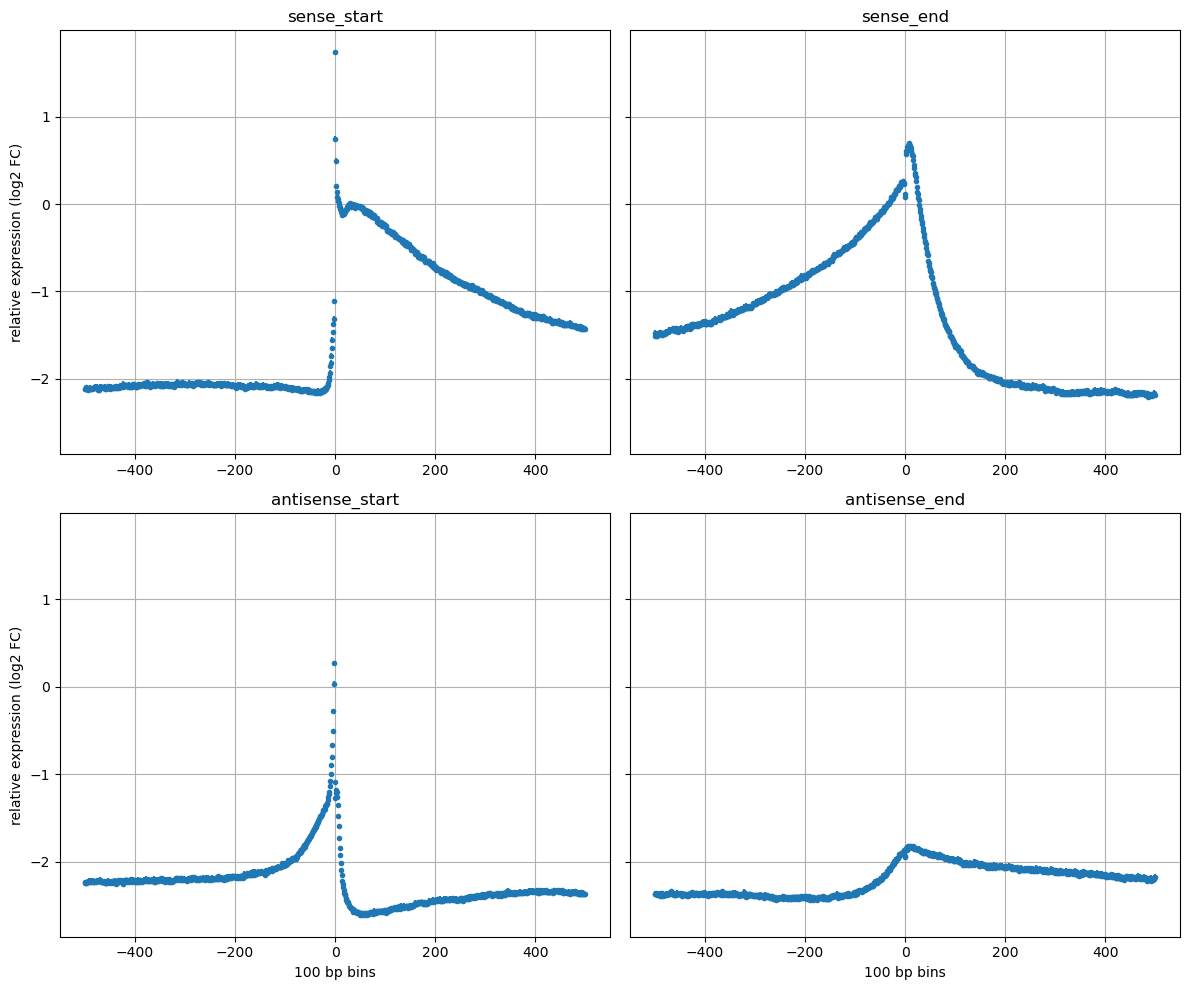

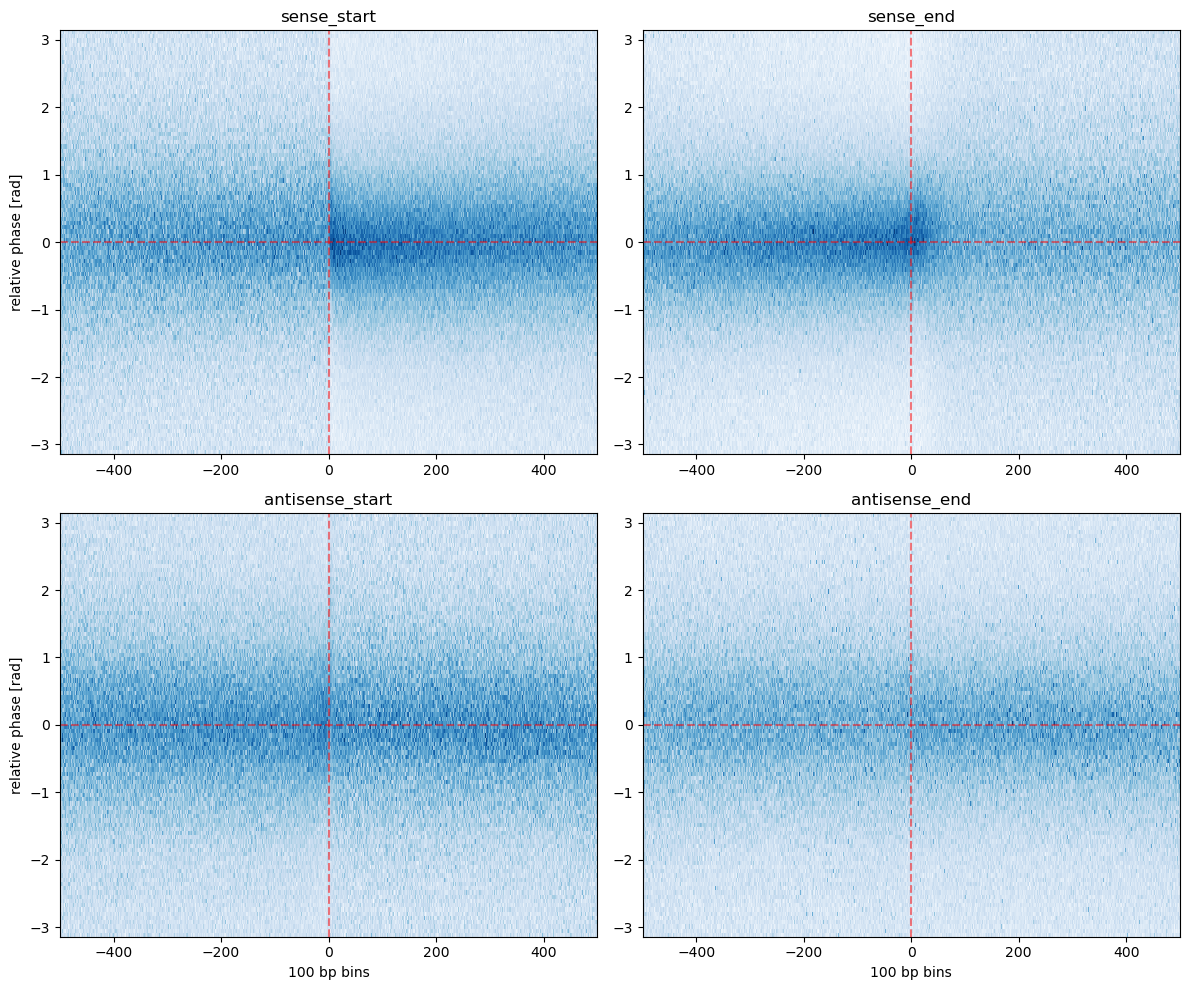

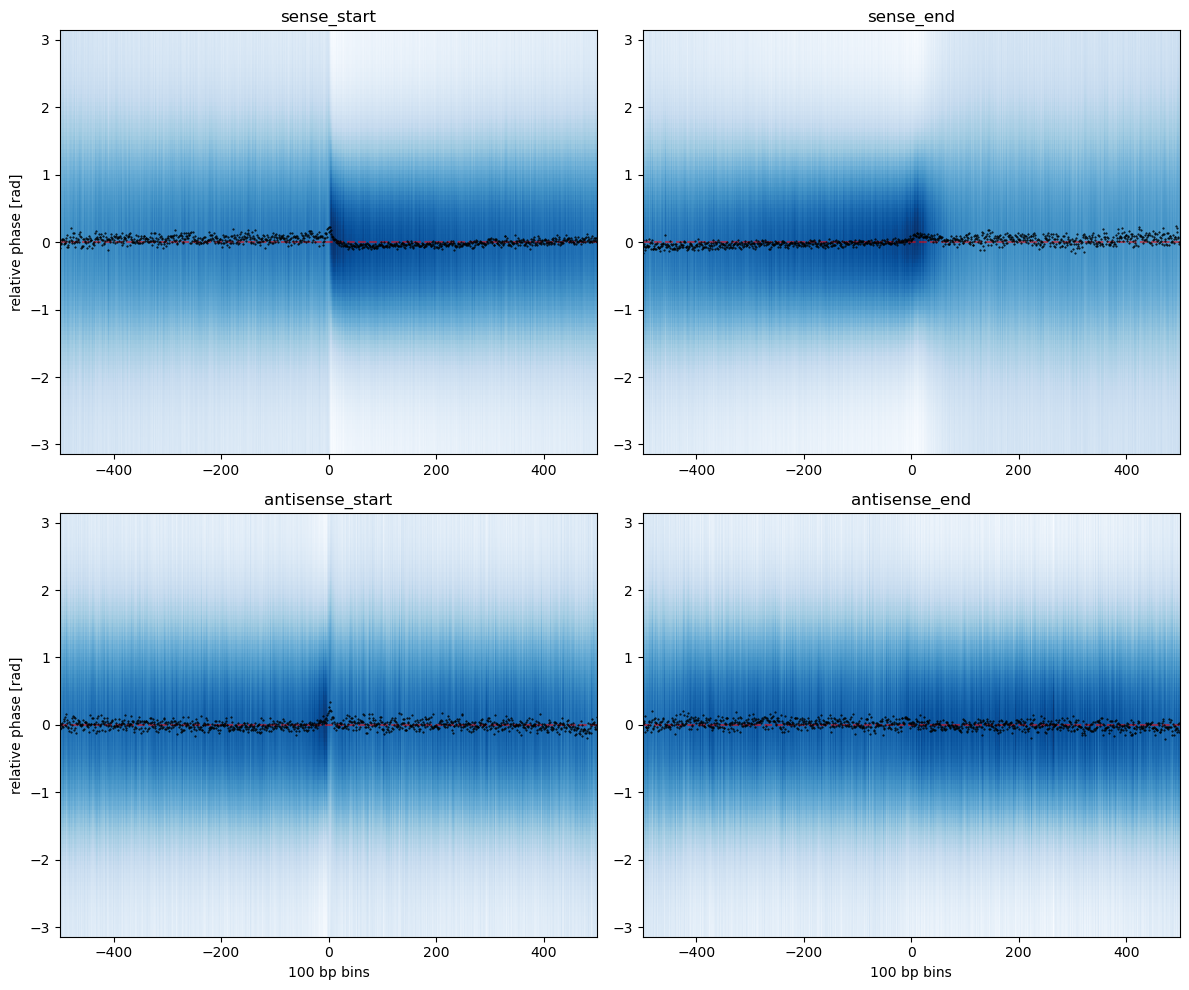

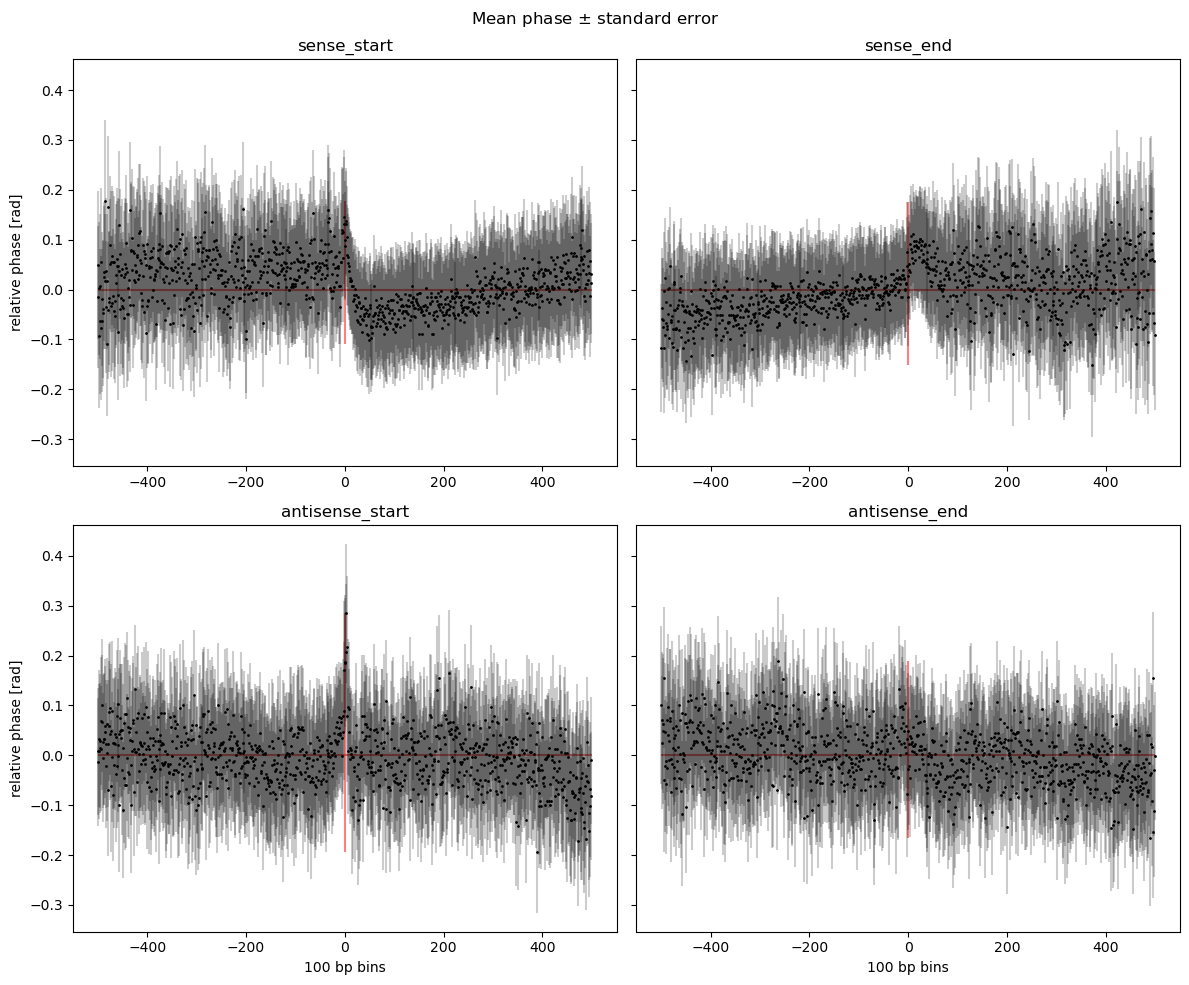

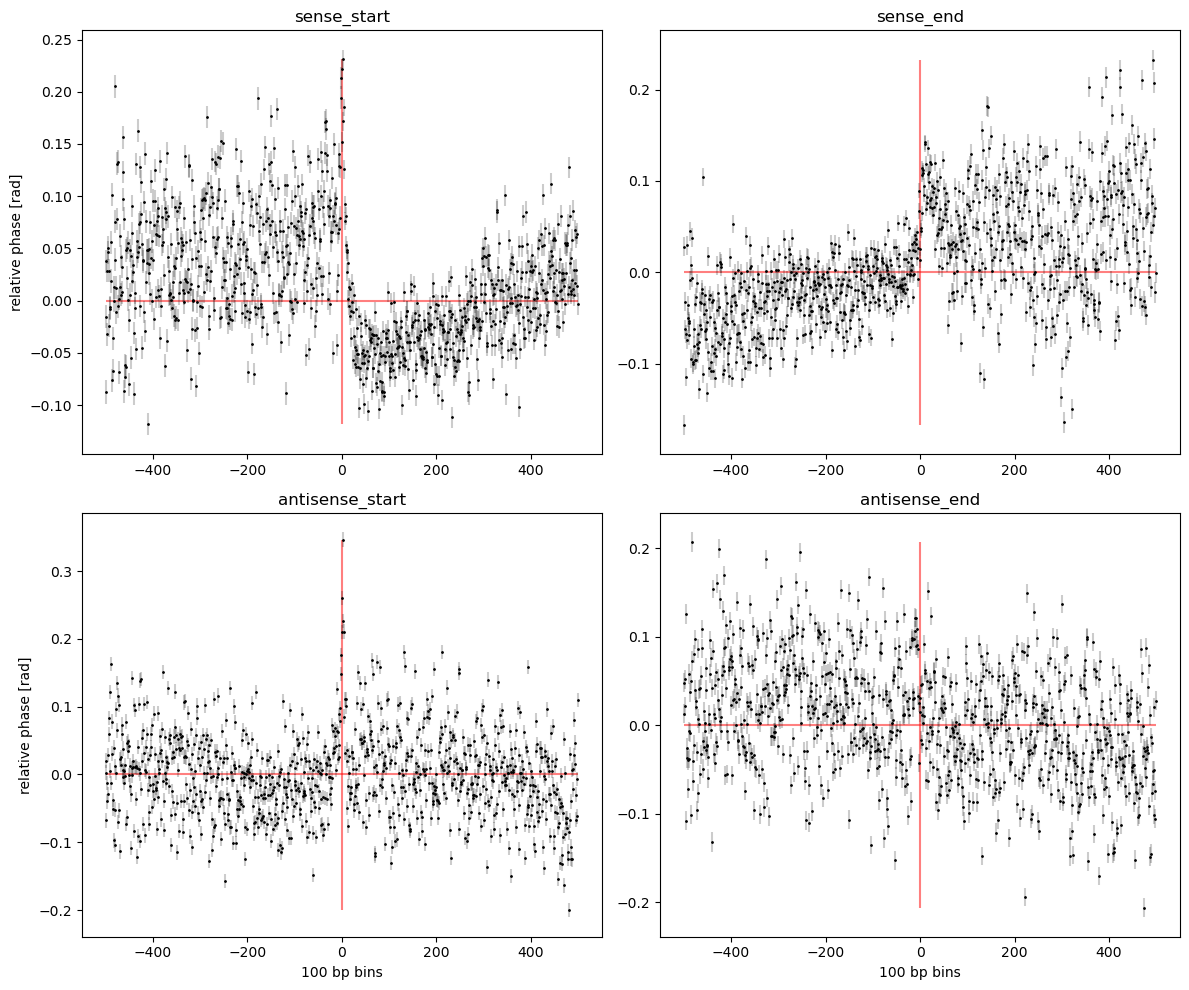

In [22]:
save_fig = False


# plot phase and amplitude of flanks
fig, axes = plt.subplots(2, 2, figsize=(12, 10),sharey=True)
axes = axes.flatten()
for i, flank in enumerate(Flank_rel_expression):
    ax = axes[i]
    ax.errorbar(x=range(-n_bins_flank,n_bins_flank),y=np.nanmean(Flank_rel_expression[flank],0),yerr=np.nanstd(Flank_rel_expression[flank],0)/np.sqrt(len(idx_top)),fmt='.')
    ax.set_title(flank)
    if flank.split('_')[0] == 'antisense':
        ax.set_xlabel(f'{bin_size} bp bins')
    # if up put xtick from -bins to 0
    #if flank.split('_')[1]  in ['up','end']:
    #    ax.set_xticks(range(0,n_bins_flank+1,50),range(-n_bins_flank,1,50))
    #else:
    #    ax.set_xticks(range(0,n_bins_flank+1,50),range(0,n_bins_flank+1,50))
    if flank.split('_')[1] == 'start':
        ax.set_ylabel('relative expression (log2 FC)')
    ax.grid()
    
fig.tight_layout()
if save_fig:
    fig.savefig('fig/Flank_expression_phase/errorbar_rel_expression.pdf',bbox_inches='tight')


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, flank in enumerate(Flank_rel_phase):
    ax = axes[i]

    ax.imshow(H[flank],aspect='auto',interpolation='none',extent=[-n_bins_flank,n_bins_flank,bins[0],bins[-1]],cmap='Blues',origin='lower')
    ax.hlines(0,-n_bins_flank,n_bins_flank,linestyle='--',color='r',alpha=.5)
    ax.vlines(0,-np.pi,np.pi,linestyle='--',color='r',alpha=.5)
    ax.set_title(flank)
    if flank.split('_')[0] == 'antisense':
        ax.set_xlabel(f'{bin_size} bp bins')
    if flank.split('_')[1] == 'start':
        ax.set_ylabel('relative phase [rad]')


fig.tight_layout()
if save_fig:
    fig.savefig('fig/Flank_expression_phase/hist_rel_phase.pdf',bbox_inches='tight')


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, flank in enumerate(Flank_rel_phase):
    ax = axes[i]

    ax.imshow(VM[flank],aspect='auto',interpolation='none',extent=[-n_bins_flank,n_bins_flank,bins[0],bins[-1]],cmap='Blues',origin='lower')
    ax.errorbar(x=range(-n_bins_flank,n_bins_flank),y=MU_SIGMA2[flank][0,:],yerr=0*np.sqrt(MU_SIGMA2[flank][1,:]),fmt='.',color='k',markersize=1)
    ax.hlines(0,-n_bins_flank,n_bins_flank,linestyle='--',color='r',alpha=.5)
    ax.set_title(flank)
    if flank.split('_')[0] == 'antisense':
        ax.set_xlabel(f'{bin_size} bp bins')
    if flank.split('_')[1] == 'start':
        ax.set_ylabel('relative phase [rad]')

fig.tight_layout()
if save_fig:
    fig.savefig('fig/Flank_expression_phase/vonmises_rel_phase.pdf',bbox_inches='tight')


fig, axes = plt.subplots(2, 2, figsize=(12, 10),sharey=True)
axes = axes.flatten()
for i, flank in enumerate(Flank_rel_phase):
    ax = axes[i]

    w = Flank_amp[flank]*Flank_R2[flank]
    w = w / np.nansum(w,0)  # normalize weights
    #mu = np.nanmean( Flank_rel_phase[flank]*w,0)/np.nanmean(w,0)
    #std = np.nanstd( Flank_rel_phase[flank],0)/np.sqrt(np.sum( ~np.isnan(Flank_rel_phase[flank]), 0 ))

    C_1 = np.cos(Flank_rel_phase[flank])
    S_1 = np.sin(Flank_rel_phase[flank])
    R_1 = np.sqrt(C_1**2 + S_1**2)
    C_1_m = np.nansum(C_1*w,0)
    S_1_m = np.nansum(S_1*w,0) 
    R_1_m = np.nansum(R_1*w,0)
    T_1 = np.arctan2(S_1_m, C_1_m)

    C_2 = np.cos(2*Flank_rel_phase[flank])/2
    S_2 = np.sin(2*Flank_rel_phase[flank])/2
    R_2 = np.sqrt(C_2**2 + S_2**2)
    C_2_m = np.nansum(C_2*w,0)
    S_2_m = np.nansum(S_2*w,0)
    R_2_m = np.nansum(R_2*w,0)
    T_2 = np.arctan2(S_2_m, C_2_m)
    
    n = (~np.isnan(x)).sum(0)
    mu = T_1
    std = np.sqrt(-2*np.log(R_1_m) )
    #std_err = std / np.sqrt(n)
    std_err = (1-T_2)/(2*R_1_m**2)
    #std_err = np.sqrt(1 - R**2) / (R * n)

    a = np.nansum(np.cos(Flank_rel_phase[flank])*w,0)
    b = np.nansum(np.sin(Flank_rel_phase[flank])*w,0)
    σ2_a = np.sqrt(np.nansum((np.cos(Flank_rel_phase[flank]) - a)**2 * w,0))
    σ2_b = np.sqrt(np.nansum((np.sin(Flank_rel_phase[flank]) - b)**2 * w,0))

    A = np.sqrt(a**2 + b**2)
    σ2_A = (np.abs(a)*σ2_a + np.abs(b)*σ2_b)/A
    mu = np.arctan2(b, a)
    σ2_φ = (np.abs(b)*σ2_a + np.abs(a)*σ2_b)/A**2
    std_err = np.sqrt(σ2_φ/n)


    ax.hlines(0,-n_bins_flank,n_bins_flank,linestyle='-',color='r',alpha=.5)
    ax.vlines(0,mu.min(),mu.max(),linestyle='-',color='r',alpha=.5)
    ax.errorbar(range(-n_bins_flank,n_bins_flank),y=mu,yerr=std_err,fmt='.',color='k',markersize=0,alpha=0.2)
    ax.plot(range(-n_bins_flank,n_bins_flank),mu,'.',color='k',markersize=2)
    ax.set_title(flank)
    if flank.split('_')[0] == 'antisense':
        ax.set_xlabel(f'{bin_size} bp bins')

    if flank.split('_')[1] == 'start':
        ax.set_ylabel('relative phase [rad]')

fig.suptitle(r'Mean phase $\pm$ standard error')
fig.tight_layout()
if save_fig:
    fig.savefig('fig/Flank_expression_phase/errorbar_rel_phase_mean_stderr.pdf',bbox_inches='tight')


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, flank in enumerate(Flank_rel_phase):
    ax = axes[i]
    ax.hlines(0,-n_bins_flank,n_bins_flank,linestyle='-',color='r',alpha=.5)
    ax.vlines(0,MU_SIGMA2[flank][0,:].min(),MU_SIGMA2[flank][0,:].max(),linestyle='-',color='r',alpha=.5)
    ax.errorbar(x=range(-n_bins_flank,n_bins_flank),y=MU_SIGMA2[flank][0,:],yerr=np.sqrt(MU_SIGMA2[flank][1,:]/idx_top.shape[0]),fmt='.',color='k',markersize=0,alpha=0.2)
    ax.plot(range(-n_bins_flank,n_bins_flank),MU_SIGMA2[flank][0,:],'.',color='k',markersize=2)
    ax.set_title(flank)
    if flank.split('_')[0] == 'antisense':
        ax.set_xlabel(f'{bin_size} bp bins')
    if flank.split('_')[1] == 'start':
        ax.set_ylabel('relative phase [rad]')

fig.tight_layout()
if save_fig:
    fig.savefig('fig/Flank_expression_phase/errorbar_vanmises_mean_stderr.pdf',bbox_inches='tight')



Text(0.5, 1.0, '[0.91497545]')

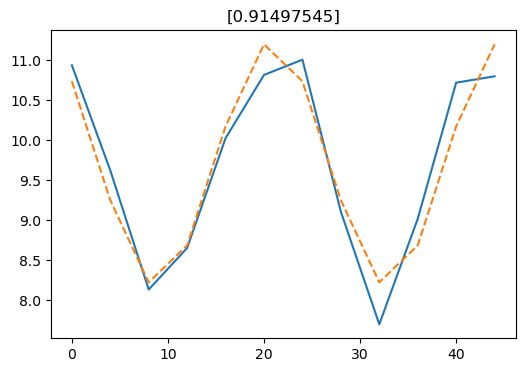

In [7]:
coord = ['chr7',113207465,113314126,'+']

n_bins_flank = 1

ω = 2*np.pi/24
T = np.arange(0,48,4)
N = T.shape[0]

# get gene coordinates and opposite strand ( - if + and + if -)
chr, start, end, strand = coord
strand_opp = '+-'.replace(strand,'')

# get gene mean expression
X = get_expression_in_window(f'{chr}:{start}:{end}:{strand}', bin_size)
MU = X.values.mean()

flank_size = n_bins_flank*bin_size

x = get_expression_in_window(f'{chr}:{start}:{start+flank_size}:{strand}', bin_size)
#Flanks['sense_end']       = get_expression_in_window(f'{chr}:{end-flank_size}:{end+flank_size}:{strand}', bin_size)
#Flanks['antisense_start'] = get_expression_in_window(f'{chr}:{start-flank_size}:{start+flank_size}:{strand_opp}', bin_size)
#Flanks['antisense_end']   = get_expression_in_window(f'{chr}:{end-flank_size}:{end+flank_size}:{strand_opp}', bin_size)

# make sure that the retrieved matrix have n_bins_flank+1 bins

if x.shape[0] != n_bins_flank:
    x = x.iloc[1:,:]
x = x.values

idx_out = x.var(1) < 1e-10

f_flanks = np.sum( x * np.exp(1j*ω*T) ,1)
f_flanks[idx_out] = np.nan

μ = x.mean(1)
φ = np.arctan2(np.imag(f_flanks),np.real(f_flanks))
A = 2*np.abs(f_flanks)/N

x_hat = μ[:,None] + A[:,None] * np.cos(ω * T[None,:] - φ[:,None])
sig2_res = np.var(x - x_hat,1)
sig2_tot = np.var(x,1)
R2 = np.zeros(sig2_res.shape)
R2[sig2_tot==0] = 0
R2[sig2_tot!=0] = 1 - sig2_res[sig2_tot!=0] / sig2_tot[sig2_tot!=0]

f_mean = np.nanmean( f_flanks )
φ_mean = np.arctan2(np.imag(f_mean),np.real(f_mean))

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(T, x.T, label='Expression')
ax.plot(T, x_hat.T, label='Fit', linestyle='--')
ax.set_title(R2)


In [8]:
2*A

array([3.04154858])